In [7]:
import pandas as pd
import matplotlib.pyplot as plt

features = pd.read_excel("smartphone_battery_features.xlsx")
targets = pd.read_excel("smartphone_battery_targets.xlsx")

data = features.merge(targets, on="Device_ID")
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]

charging_vars = [
    "avg_charging_cycles_per_week",
    "fast_charging_usage_percent",
    "overnight_charging_freq_per_week",
    "charging_habit_score"
]

data.head()

,Device_ID,device_age_months,battery_capacity_mah,avg_charging_cycles_per_week,fast_charging_usage_percent,overnight_charging_freq_per_week,charging_habit_score,background_app_usage_level,signal_strength_avg,video_streaming_hours_per_week,gaming_hours_per_week,avg_screen_on_hours_per_day,usage_intensity_score,thermal_stress_index,avg_battery_temp_celsius,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,11.4,90.8,7,4,Medium,Poor,14.0,7.9,7.1,10.0,4.04,34.8,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,10.3,60.6,2,7,Medium,Good,11.0,8.6,6.8,10.0,4.23,35.4,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,11.2,29.3,4,6,Medium,Good,10.3,0.3,7.2,10.0,2.21,29.4,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,8.3,62.5,0,8,Medium,Good,4.9,1.9,5.5,10.0,3.13,32.8,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,11.6,85.4,6,5,High,Good,9.3,7.9,7.6,10.0,4.95,38.7,67.2,Replace Battery


Missing values:
avg_charging_cycles_per_week        0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
charging_habit_score                0
dtype: int64

Descriptive statistics:


,avg_charging_cycles_per_week,fast_charging_usage_percent,overnight_charging_freq_per_week,charging_habit_score
count,5000.00000,5000.000000,5000.000000,5000.000000
mean,8.33224,50.712400,3.465200,6.582000
std,3.03454,22.227398,2.306307,1.225225
min,3.00000,1.100000,0.000000,3.000000
25%,6.10000,33.500000,1.000000,6.000000
50%,8.25000,51.000000,3.000000,7.000000
75%,10.40000,68.100000,5.000000,7.000000
max,18.60000,99.100000,7.000000,10.000000


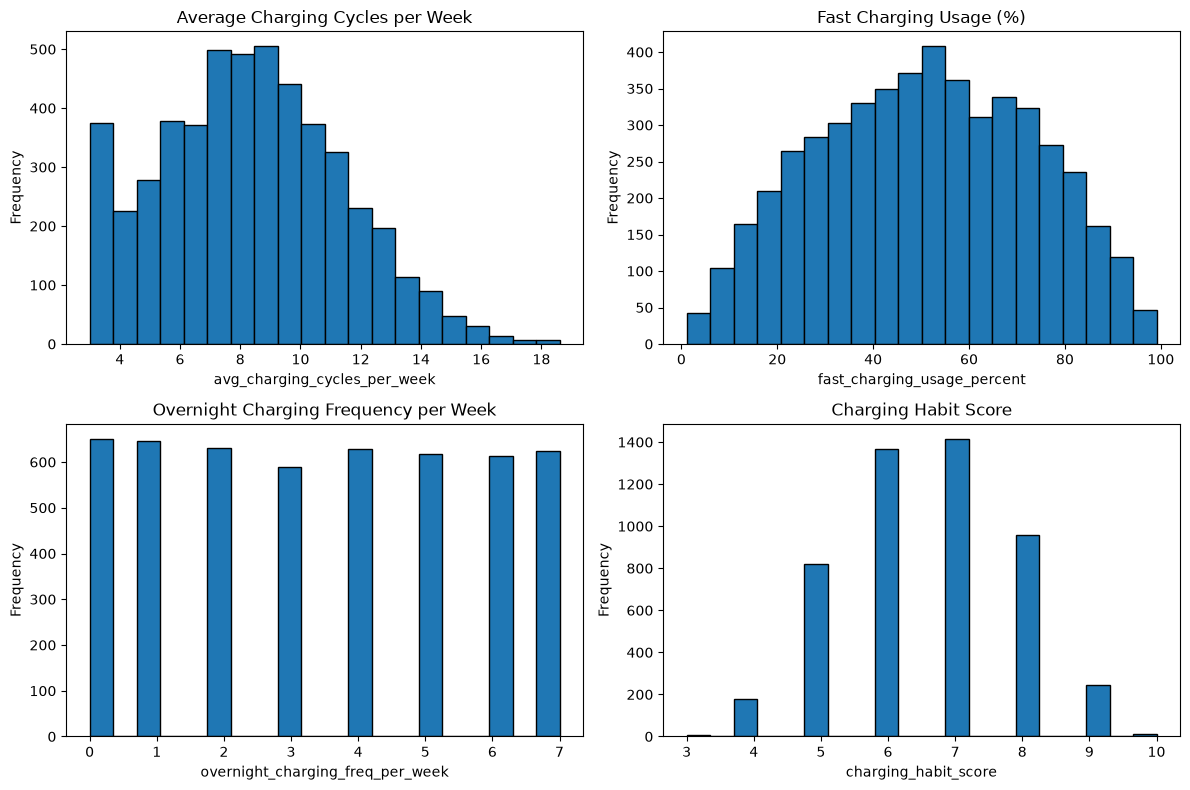

In [8]:
print("Missing values:")
print(data[charging_vars].isnull().sum())

print("\nDescriptive statistics:")
display(data[charging_vars].describe())

titles = [
    "Average Charging Cycles per Week",
    "Fast Charging Usage (%)",
    "Overnight Charging Frequency per Week",
    "Charging Habit Score"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, variable, title in zip(axes.flatten(), charging_vars, titles):
    ax.hist(data[variable], bins=20, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel(variable)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

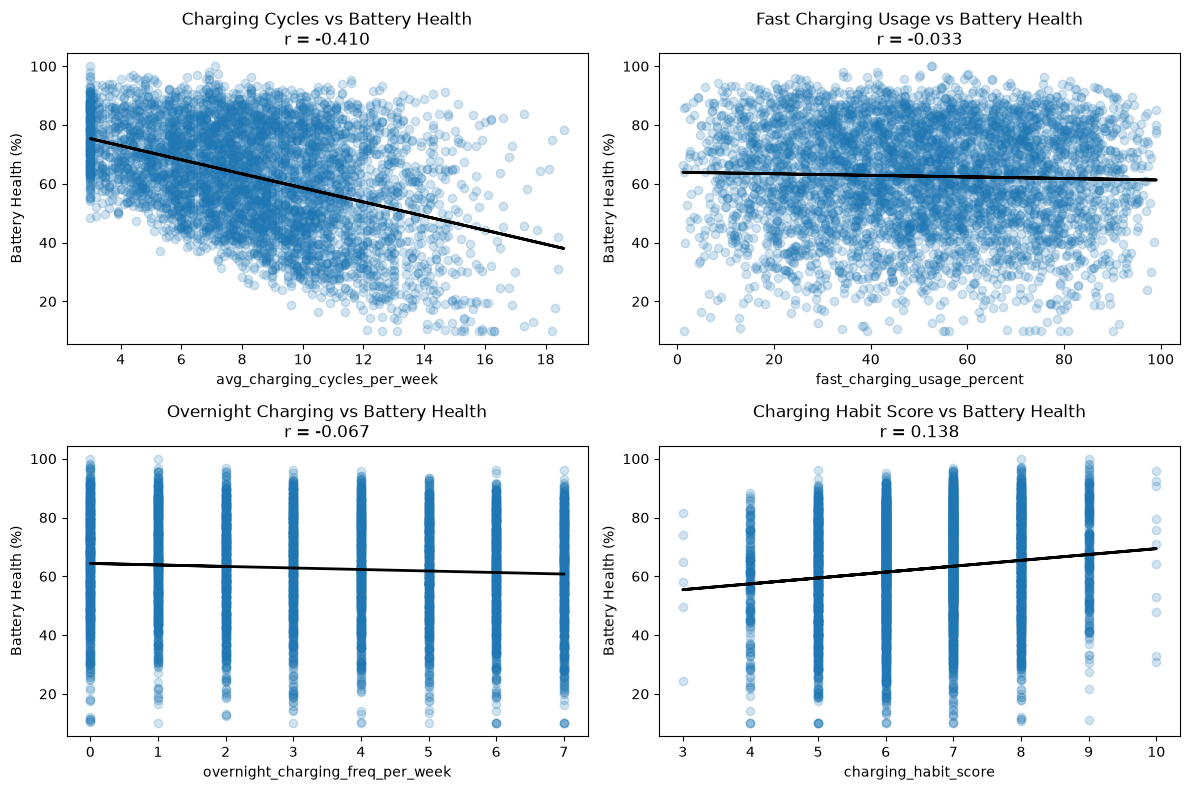

In [9]:
target = "current_battery_health_percent"

scatter_titles = [
    "Charging Cycles vs Battery Health",
    "Fast Charging Usage vs Battery Health",
    "Overnight Charging vs Battery Health",
    "Charging Habit Score vs Battery Health"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, variable, title in zip(
    axes.flatten(),
    charging_vars,
    scatter_titles
):
    x = data[variable]
    y = data[target]

    ax.scatter(x, y, alpha=0.2)

    r = x.corr(y)

    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m*x + b, color="black", linewidth=2)

    ax.set_title(f"{title}\nr = {r:.3f}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Battery Health (%)")

plt.tight_layout()
plt.show()

note : charging cycle as variable
